# Pricing Options: From Black–Scholes to Monte Carlo
## Step 4 — The Black–Scholes Formula

**Target audience:** second-year undergraduate students  
**Goal of this notebook:** understand how the Black–Scholes formula prices European options, where the formula comes from at a conceptual level, and how its parameters affect option values.

---

## Learning objectives

At the end of this notebook, the student should be able to:

- explain the idea of **dynamic hedging**,
- understand why the **no-arbitrage principle** leads to a pricing formula,
- write the Black–Scholes formulas for a European call and a European put,
- interpret the quantities $d_1$ and $d_2$,
- identify the role of each parameter: $S_0$, $K$, $T$, $r$, and $\sigma$,
- compute a Black–Scholes price in Python,
- understand the relation between the call and put prices through **put–call parity**.


## 1. Where are we in the story?

In the previous notebooks, we introduced:

- what options are,
- the assumptions of the Black–Scholes model,
- and the geometric Brownian motion model for the stock price.

We now move to the next big step:

> **How do we obtain a price for a European option today?**

The answer relies on two major ideas:

1. **no arbitrage**,
2. **dynamic hedging**.


## 2. The key financial idea: replication

Suppose we want to price a European call option.
Its payoff at maturity is

$$
(S_T - K)^+ = \max(S_T - K, 0).
$$

The Black–Scholes idea is the following:

> If we can build a portfolio of traded assets that produces exactly the same payoff as the option at maturity, then this portfolio and the option must have the same price today.

Otherwise, there would be an arbitrage opportunity.

This idea is called **replication**.


## 3. Dynamic hedging in words

The option payoff depends on the stock price, which is random.
So the replicating portfolio cannot simply be fixed once and for all.
It must be adjusted through time.

This leads to the idea of **dynamic hedging**:

- hold a certain number of shares of the stock,
- invest or borrow the remaining amount in the risk-free asset,
- continuously rebalance the portfolio.

Under the Black–Scholes assumptions, this dynamic strategy can replicate the option payoff exactly.

This is the deep reason why a closed-form pricing formula exists.


## 4. Why does volatility matter so much?

A call option benefits from upside movements of the stock, while its downside is limited by zero payoff.

So if the stock becomes more volatile:

- very low prices do not hurt the call beyond making it worthless,
- very high prices can make the call very valuable.

This asymmetry explains why the value of an option generally increases with volatility.

One of the great strengths of the Black–Scholes formula is that it quantifies this effect precisely.


## 5. The Black–Scholes call and put formulas

For a European call option, the Black–Scholes price is

$$
C_0 = S_0 \Phi(d_1) - K e^{-rT} \Phi(d_2),
$$

and for a European put option,

$$
P_0 = K e^{-rT} \Phi(-d_2) - S_0 \Phi(-d_1),
$$

where

$$
d_1 = \frac{\ln(S_0/K) + \left(r + \tfrac{1}{2}\sigma^2\right)T}{\sigma \sqrt{T}},
$$

$$
d_2 = d_1 - \sigma \sqrt{T}.
$$

Here, $\Phi$ denotes the cumulative distribution function of the standard normal distribution.


## 6. Meaning of the parameters

Let us interpret each parameter in the formula.

### $S_0$ — Current stock price
This is the price of the underlying asset today.
A higher $S_0$ makes a call more valuable and a put less valuable.

### $K$ — Strike price
This is the exercise price fixed in the contract.
A higher strike makes a call less attractive and a put more attractive.

### $T$ — Time to maturity
This is the amount of time remaining before expiration.
More time usually increases the option's value because there is more opportunity for favorable price movements.

### $r$ — Risk-free interest rate
This is used to discount the strike price.
It also appears because option pricing is done in a **risk-neutral framework**.

### $\sigma$ — Volatility
This measures the magnitude of uncertainty in the stock price.
Higher volatility usually increases both call and put prices.


## 7. What are $d_1$ and $d_2$?

At first sight, $d_1$ and $d_2$ look mysterious.
But they are simply standardized quantities that combine:

- moneyness through $\ln(S_0/K)$,
- time to maturity through $T$,
- interest rate through $r$,
- uncertainty through $\sigma$.

Very roughly:

- $d_1$ appears in the stock-related term,
- $d_2$ appears in the discounted strike-related term.

You can think of them as summary indicators of where the option stands relative to the strike, after taking time and volatility into account.


## 8. Why do we use $r$ and not $\mu$?

A very important feature of the Black–Scholes formula is that the drift $\mu$ of the stock does **not** appear in the final pricing formula.

Instead, the formula uses the **risk-free rate** $r$.

Why?

Because the derivation eliminates risk by hedging.
Once the risk is hedged away, the resulting portfolio must grow at the risk-free rate in the absence of arbitrage.

This is one of the most profound insights of modern finance:

> option pricing depends on hedging and no-arbitrage, not directly on the investor's expected return $\mu$.


## 9. A first numerical example

Suppose:

- current stock price: $S_0 = 100$,
- strike: $K = 100$,
- maturity: $T = 1$ year,
- risk-free rate: $r = 5\%$,
- volatility: $\sigma = 20\%$.

We now compute the Black–Scholes prices of the European call and put.


In [1]:
import math
from math import log, sqrt, exp, erf

# Standard normal CDF using erf

def Phi(x):
    return 0.5 * (1.0 + erf(x / math.sqrt(2.0)))


def bs_call_price(S0, K, T, r, sigma):
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S0 * Phi(d1) - K * exp(-r * T) * Phi(d2)


def bs_put_price(S0, K, T, r, sigma):
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return K * exp(-r * T) * Phi(-d2) - S0 * Phi(-d1)

S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.20

call_price = bs_call_price(S0, K, T, r, sigma)
put_price = bs_put_price(S0, K, T, r, sigma)

print(f"Call price: {call_price:.4f}")
print(f"Put price : {put_price:.4f}")


Call price: 10.4506
Put price : 5.5735


### Interpretation

These are the fair Black–Scholes prices under the model assumptions.

Notice that the call and put do not have the same price, even though they are written on the same stock with the same strike and maturity.
This is because their payoffs are different.


## 10. Put–call parity

For European options written on a non-dividend-paying stock, the call and put prices satisfy the relation

$$
C_0 - P_0 = S_0 - K e^{-rT}.
$$

This is called **put–call parity**.

It is a direct consequence of no arbitrage.
It tells us that if we know the price of the call, then we can deduce the price of the corresponding put, and conversely.


In [2]:
lhs = call_price - put_price
rhs = S0 - K * math.exp(-r * T)

print(f"C0 - P0 = {lhs:.6f}")
print(f"S0 - K e^(-rT) = {rhs:.6f}")


C0 - P0 = 4.877058
S0 - K e^(-rT) = 4.877058


### Interpretation

The two quantities are equal up to numerical rounding error.
This confirms the put–call parity relation for our example.


## 11. How do prices vary with the stock price?

It is useful to visualize the price of the call and put as functions of the current stock price $S_0$.

Intuitively:

- as $S_0$ increases, the call becomes more valuable,
- as $S_0$ increases, the put becomes less valuable.


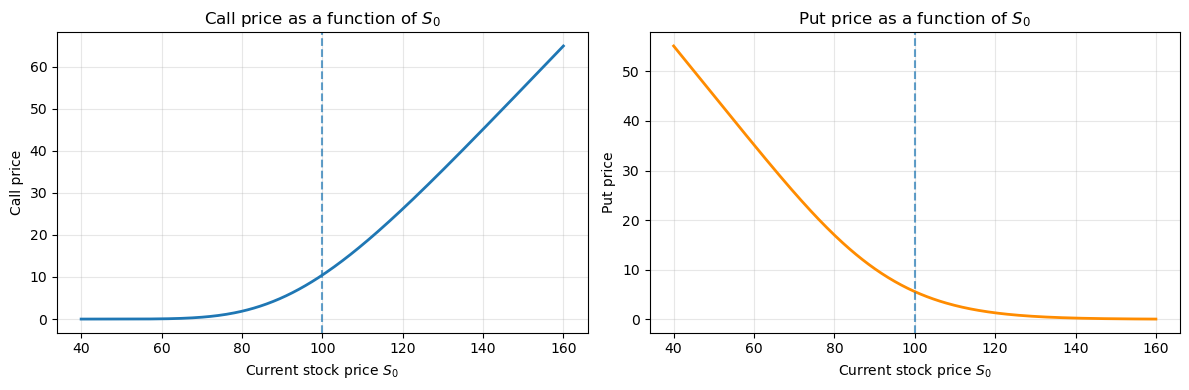

In [3]:
import numpy as np
import matplotlib.pyplot as plt

K = 100
T = 1.0
r = 0.05
sigma = 0.20
S_grid = np.linspace(40, 160, 300)

call_values = [bs_call_price(S, K, T, r, sigma) for S in S_grid]
put_values = [bs_put_price(S, K, T, r, sigma) for S in S_grid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(S_grid, call_values, lw=2)
axes[0].axvline(K, linestyle='--', alpha=0.7)
axes[0].set_title('Call price as a function of $S_0$')
axes[0].set_xlabel('Current stock price $S_0$')
axes[0].set_ylabel('Call price')
axes[0].grid(True, alpha=0.3)

axes[1].plot(S_grid, put_values, lw=2, color='darkorange')
axes[1].axvline(K, linestyle='--', alpha=0.7)
axes[1].set_title('Put price as a function of $S_0$')
axes[1].set_xlabel('Current stock price $S_0$')
axes[1].set_ylabel('Put price')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Interpretation

- The **call price** is an increasing function of the current stock price.
- The **put price** is a decreasing function of the current stock price.

This matches financial intuition.


## 12. How does volatility affect the call price?

One of the most important comparative statics in option pricing is the effect of volatility.

A higher volatility increases the range of possible future prices.
For an option, this extra uncertainty is generally favorable because the downside is limited while the upside can be large.

We now illustrate this effect numerically.


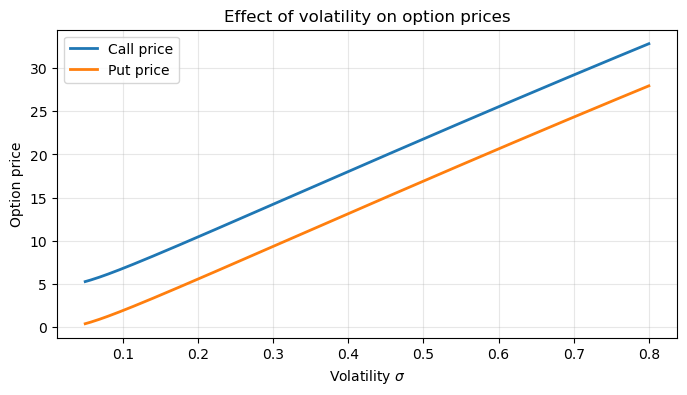

In [4]:
vol_grid = np.linspace(0.05, 0.8, 200)
call_vs_vol = [bs_call_price(100, 100, 1.0, 0.05, vol) for vol in vol_grid]
put_vs_vol = [bs_put_price(100, 100, 1.0, 0.05, vol) for vol in vol_grid]

plt.figure(figsize=(8, 4))
plt.plot(vol_grid, call_vs_vol, label='Call price', lw=2)
plt.plot(vol_grid, put_vs_vol, label='Put price', lw=2)
plt.title('Effect of volatility on option prices')
plt.xlabel('Volatility $\sigma$')
plt.ylabel('Option price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

As volatility increases, both the call price and the put price increase.

This is a key result in option theory and explains why volatility is often called the **most important input** in option pricing.


## 13. Intrinsic value and time value

An option price can be thought of as having two components.

### Intrinsic value

For a call, the intrinsic value today is

$$
\max(S_0 - K, 0).
$$

For a put, it is

$$
\max(K - S_0, 0).
$$

### Time value

The option price is generally **greater** than intrinsic value because there is still time before maturity.
This extra part is called the **time value**.

The Black–Scholes formula includes both effects automatically.


## 14. Moneyness

A useful vocabulary in option pricing is the notion of **moneyness**.

For a call option:

- **in the money (ITM):** $S_0 > K$,
- **at the money (ATM):** $S_0 \approx K$,
- **out of the money (OTM):** $S_0 < K$.

For a put option, the interpretation is reversed.

Moneyness strongly influences the option price and the shape of the Black–Scholes formula through the term $\ln(S_0/K)$.


## 15. Limits of the Black–Scholes formula

The Black–Scholes formula is elegant and powerful, but it relies on strong assumptions:

- constant volatility,
- constant interest rate,
- no transaction costs,
- continuous hedging,
- no jumps in the stock price.

Real markets often violate these assumptions.

Nevertheless, the formula remains fundamental because:

- it provides a benchmark,
- it gives intuition,
- it is the starting point for more advanced models,
- and it is still widely used in practice.


## 16. Summary

### Main ideas to remember

- The Black–Scholes price is derived using **no arbitrage** and **dynamic hedging**.
- The European call price is
  $$C_0 = S_0 \Phi(d_1) - K e^{-rT} \Phi(d_2).$$
- The European put price is
  $$P_0 = K e^{-rT} \Phi(-d_2) - S_0 \Phi(-d_1).$$
- The formula depends on $S_0$, $K$, $T$, $r$, and $\sigma$.
- The stock drift $\mu$ does not appear in the final pricing formula.
- Put and call prices are linked by **put–call parity**.
- Volatility has a major positive effect on option prices.


## 17. Exercises for the student

1. Why does the Black–Scholes formula use $r$ instead of $\mu$?
2. Explain in words the idea of dynamic hedging.
3. What happens to the call price if $S_0$ increases?
4. What happens to the put price if $S_0$ increases?
5. Why do both call and put prices increase when volatility increases?
6. State the put–call parity formula.
7. For a call option, what does it mean to be in the money?


## 18. What comes next?

Now that we have the closed-form Black–Scholes formula, the next natural step is to move toward simulation methods.

### **Notebook 5 — Monte Carlo pricing of a European option**

In the next notebook, we can explain:

- how to simulate terminal stock prices,
- how to estimate the expected payoff,
- how discounting works,
- and how Monte Carlo approximates the Black–Scholes price.
